
Результаты применения критериев:
Сценарий                  Инверсий             Вальда-Вольфовица         Рамачандрана         Серий знаков        
                          I*         p          Ns*          p            RR         >370       S*         p         
------------------------------------------------------------------------------------------------------------------------
1: Белый шум              -0.4825    0.6295     0.2010       0.8407       254        0          -0.1604    0.8726    
2: Тренд +0.01            -3.5320    0.0004     -1.2061      0.2278       320        0          -0.1604    0.8726    
3: Тренд -0.5             14.2533    0.0000     -9.4478      0.0000       4804       1          -2.0850    0.0371    
4: Синусоида              7.6597     0.0000     -8.8448      0.0000       4338       1          0.0802     0.9361    
5: Выброс                 -0.4765    0.6337     -0.2010      0.8407       266        0          -0.1604    0.8726    


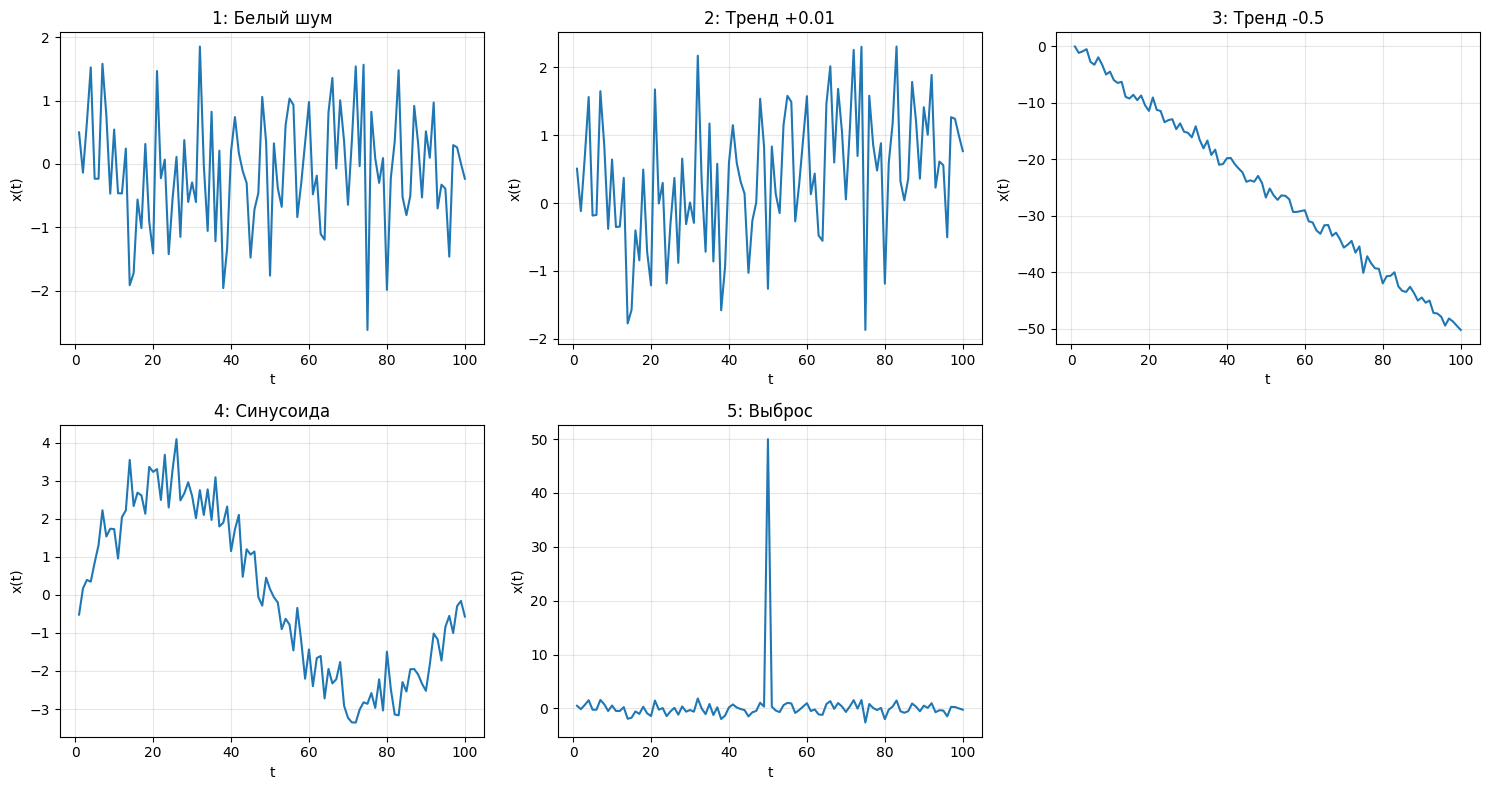

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
n = 100
alpha = 0.05
z_crit = stats.norm.ppf(1 - alpha/2)

# Генерация временных рядов
t = np.arange(1, n+1)
eps1 = np.random.normal(0, 1, n)
x1 = eps1
x2 = 0.01*t + eps1
x3 = -0.5*t + eps1
eps4 = np.random.normal(0, 0.5, n)
x4 = 3 * np.sin(2*np.pi*t/100) + eps4
x5 = x1.copy()
x5[49] = 50

series = {
    "1: Белый шум": x1,
    "2: Тренд +0.01": x2,
    "3: Тренд -0.5": x3,
    "4: Синусоида": x4,
    "5: Выброс": x5
}

# Критерий инверсий
def inversion_test(x):
    n = len(x)
    inv = 0
    for i in range(n):
        inv += np.sum(x[i+1:] < x[i])
    E = n*(n-1)/4
    D = n*(2*n+5)*(n-1)/72
    I_star = (inv - E)/np.sqrt(D)
    p = 2*(1 - stats.norm.cdf(abs(I_star)))
    return I_star, p

# Сериальный критерий Вальда-Вольфовица
def wald_wolfowitz_test(x):
    med = np.median(x)
    symbols = np.where(x >= med, 'a', 'b')
    n_a = np.sum(symbols == 'a')
    n_b = len(x) - n_a
    series = 1
    for i in range(1, len(x)):
        if symbols[i] != symbols[i-1]:
            series += 1
    num = series - (2*n_a*n_b/(n_a+n_b) + 1)
    den = np.sqrt((2*n_a*n_b*(2*n_a*n_b - n_a - n_b)) / ((n_a+n_b)**2*(n_a+n_b-1)))
    Ns_star = num / den if den != 0 else 0
    p = 2*(1 - stats.norm.cdf(abs(Ns_star)))
    return Ns_star, p

# Критерий Рамачандрана-Ранганатана
def ramachandran_rangarajan_test(x):
    med = np.median(x)
    symbols = np.where(x >= med, 1, 0)
    runs = []
    cur_len = 1
    for i in range(1, len(x)):
        if symbols[i] == symbols[i-1]:
            cur_len += 1
        else:
            runs.append(cur_len)
            cur_len = 1
    runs.append(cur_len)
    rr = sum(j**2 for j in runs)
    crit_95 = 370
    reject = rr > crit_95
    return rr, crit_95, reject

# Критерий серий знаков первых разностей
def sign_series_test(x):
    signs = np.diff(x)
    signs = np.where(signs > 0, 1, np.where(signs < 0, -1, 0))
    signs = signs[signs != 0]
    if len(signs) == 0:
        return np.nan, np.nan
    series = 1
    for i in range(1, len(signs)):
        if signs[i] != signs[i-1]:
            series += 1
    m = len(signs)
    E = (2*m - 1)/3
    D = (16*m - 29)/90
    S_star = (series - E)/np.sqrt(D)
    p = 2*(1 - stats.norm.cdf(abs(S_star)))
    return S_star, p

# Применение критериев
print("\nРезультаты применения критериев:")
print("="*120)
print(f"{'Сценарий':<25} {'Инверсий':<20} {'Вальда-Вольфовица':<25} {'Рамачандрана':<20} {'Серий знаков':<20}")
print(f"{'':25} {'I*':<10} {'p':<10} {'Ns*':<12} {'p':<12} {'RR':<10} {'>370':<10} {'S*':<10} {'p':<10}")
print("-"*120)

for name, x in series.items():
    I_star, p_inv = inversion_test(x)
    Ns_star, p_wald = wald_wolfowitz_test(x)
    rr, crit, rej_rr = ramachandran_rangarajan_test(x)
    S_star, p_sign = sign_series_test(x)

    print(f"{name:<25} {I_star:<10.4f} {p_inv:<10.4f} {Ns_star:<12.4f} {p_wald:<12.4f} {rr:<10} {rej_rr:<10} {S_star:<10.4f} {p_sign:<10.4f}")

# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (name, x) in enumerate(series.items()):
    axes[idx].plot(t, x)
    axes[idx].set_title(name)
    axes[idx].set_xlabel('t')
    axes[idx].set_ylabel('x(t)')
    axes[idx].grid(True, alpha=0.3)

axes[5].axis('off')
plt.tight_layout()
plt.show()